# Conformal Prediction for Directed Graph Link Prediction

This notebook presents a **directed link prediction** framework using **split conformal prediction** on the **Wikivitals** dataset. This produce prediction sets $C(x) \subseteq \{0, 1\}$ with guaranteed coverage at a chosen confidence level (e.g., 90%).

## Key Differences from Undirected Graphs

1. **Asymmetric adjacency matrix**: $A_{ij} \neq A_{ji}$ in general
2. **Directed embeddings**: Separate source and target embeddings
3. **In-degree and out-degree**: Two distinct degree metrics per node
4. **Directed features**: Asymmetric similarity and structural features

In [8]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sknetwork.embedding import SVD
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

## 1. Mathematical Foundations

### 1.1 Directed Graph Representation

A directed graph $G = (V, E)$ consists of:
- A set of vertices $V = \{v_1, v_2, \ldots, v_n\}$
- A set of directed edges $E \subseteq V \times V$, where $(u, v) \in E$ represents an edge from $u$ to $v$

The **adjacency matrix** $A \in \{0,1\}^{n \times n}$ is defined as:

$$
A_{ij} = \begin{cases}
1 & \text{if } (v_i \to v_j) \in E \\
0 & \text{otherwise}
\end{cases}
$$

Note: $A_{ij} = 1$ does NOT imply $A_{ji} = 1$ (asymmetry).

### 1.2 Node Degree Metrics

For a directed graph, each node $v_i$ has two degree measures:

**Out-degree** (number of outgoing edges):
$$
d^{\text{out}}_i = \sum_{j=1}^{n} A_{ij}
$$

**In-degree** (number of incoming edges):
$$
d^{\text{in}}_i = \sum_{j=1}^{n} A_{ji}
$$

### 1.3 Conformal Quantile

For a calibration set of scores $S = \{s_1, s_2, \ldots, s_n\}$ and error rate $\alpha \in (0,1)$, the conformal quantile is:

$$
\hat{q}_{1-\alpha} = \text{Quantile}\left(S, \frac{\lceil (n+1)(1-\alpha) \rceil}{n}\right)
$$

This ensures marginal coverage: $\mathbb{P}(Y \in C(X)) \geq 1 - \alpha$.

In [9]:
def conformal_quantile(scores, alpha):
    """
    Compute the (1-alpha) conformal quantile.
    
    Parameters:
    -----------
    scores : array-like
        Calibration scores
    alpha : float
        Target error rate (e.g., 0.1 for 90% coverage)
    
    Returns:
    --------
    float : The conformal quantile threshold
    """
    n = len(scores)
    q = np.quantile(scores, np.ceil((n + 1) * (1 - alpha)) / n)
    return q

print("Conformal quantile function ready.")

Conformal quantile function ready.


## 2. Directed Graph Data Loading

### 2.1 Directed Adjacency Matrix Construction

For a directed graph, we construct the adjacency matrix **without** symmetrization:

$$
A_{ij} = 1 \iff (i \to j) \in E
$$

Key constraints:
- No self-loops: $A_{ii} = 0$ for all $i$
- Asymmetric: $A_{ij}$ is independent of $A_{ji}$

The input file format is:
```
source_node    target_node    True
```

where each line represents a directed edge from `source_node` to `target_node`.

In [10]:
def load_directed_graph_sparse(path):
    """
    Load a directed graph from a TSV file.
    
    Parameters:
    -----------
    path : str
        Path to adjacency.tsv file with columns: source, target, True
    
    Returns:
    --------
    scipy.sparse.csr_matrix : Directed adjacency matrix A where A[i,j] = 1 means i -> j
    """
    df = pd.read_csv(path, sep='\t', header=None, usecols=[0,1], names=['source', 'target'])
    
    # For directed graphs, we do NOT add reverse edges
    rows = df['source'].values
    cols = df['target'].values
    data = np.ones(len(rows))
    
    n_nodes = max(rows.max(), cols.max()) + 1
    
    # Create directed adjacency matrix
    adj = sp.csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))
    
    # Remove duplicates and self-loops
    adj.data = np.ones_like(adj.data)
    adj.setdiag(0)
    adj.eliminate_zeros()
    
    return adj

print("Directed graph loader ready.")

Directed graph loader ready.


## 3. Directed Graph Embeddings

### 3.1 Spectral Embeddings via SVD

For a directed adjacency matrix $A \in \mathbb{R}^{n \times n}$, we apply **Singular Value Decomposition**:

$$
A \approx U \Sigma V^T
$$

where:
- $U \in \mathbb{R}^{n \times k}$: **Source node embeddings** (captures outgoing edge patterns)
- $V \in \mathbb{R}^{n \times k}$: **Target node embeddings** (captures incoming edge patterns)
- $\Sigma \in \mathbb{R}^{k \times k}$: Singular values (diagonal)
- $k$: Embedding dimension (e.g., 32)

This gives us:
- **Source embedding** for node $i$: $u_i \in \mathbb{R}^k$ (row $i$ of $U$)
- **Target embedding** for node $j$: $v_j \in \mathbb{R}^k$ (row $j$ of $V$)

The reconstruction approximates: $A_{ij} \approx u_i^T \Sigma v_j$

### 3.2 Why Two Embeddings?

In directed graphs:
- A node's **role as a source** (outgoing edges) differs from its **role as a target** (incoming edges)
- Example: In a citation network, a paper cited by many (high in-degree) may cite few (low out-degree)
- Separate embeddings capture these asymmetric roles

In [11]:
def get_directed_node_features(adj, n_components=32):
    """
    Extract node features for directed graphs.
    
    Parameters:
    -----------
    adj : scipy.sparse matrix
        Directed adjacency matrix
    n_components : int
        Embedding dimension
    
    Returns:
    --------
    out_degrees : array, shape (n_nodes,)
        Out-degree of each node
    in_degrees : array, shape (n_nodes,)
        In-degree of each node
    source_embedding : array, shape (n_nodes, n_components)
        Source (row) embeddings from SVD
    target_embedding : array, shape (n_nodes, n_components)
        Target (column) embeddings from SVD
    """
    # Out-degrees: sum along columns (axis=1)
    out_degrees = np.array(adj.sum(axis=1)).flatten()
    
    # In-degrees: sum along rows (axis=0)
    in_degrees = np.array(adj.sum(axis=0)).flatten()
    
    # SVD Embeddings
    print(f"Computing SVD Embeddings (Rank {n_components}) for directed graph...")
    svd = SVD(n_components=n_components)
    
    # For directed graphs, sknetwork SVD returns row embeddings (U) and col embeddings (V)
    # fit_transform returns row embeddings (source embeddings)
    source_embedding = svd.fit_transform(adj)
    
    # Get column embeddings V (target embeddings) using correct sknetwork attribute
    target_embedding = svd.embedding_col_
    
    return out_degrees, in_degrees, source_embedding, target_embedding

print("Directed feature extractor ready.")

Directed feature extractor ready.


## 4. Feature Engineering for Directed Edge Prediction

### 4.1 Directed Edge Features

For a candidate directed edge $(u \to v)$, we construct feature vector $x_{u \to v}$:

$$
x_{u \to v} = \begin{bmatrix}
d^{\text{out}}_u \\
d^{\text{in}}_v \\
d^{\text{in}}_u \\
d^{\text{out}}_v \\
\text{sim}(u, v) \\
\text{sim}_{\text{reverse}}(v, u)
\end{bmatrix} \in \mathbb{R}^6
$$

where:

**Degree features** (capture node importance):
- $d^{\text{out}}_u$: Out-degree of source node (how many nodes $u$ points to)
- $d^{\text{in}}_v$: In-degree of target node (how many nodes point to $v$)
- $d^{\text{in}}_u$: In-degree of source node
- $d^{\text{out}}_v$: Out-degree of target node

**Directed similarity** (captures embedding compatibility):

$$
\text{sim}(u, v) = \frac{u_{\text{source}} \cdot v_{\text{target}}}{\|u_{\text{source}}\| \|v_{\text{target}}\|}
$$

This measures how well $u$'s outgoing pattern matches $v$'s incoming pattern.

**Reverse similarity** (captures potential reciprocity):

$$
\text{sim}_{\text{reverse}}(v, u) = \frac{v_{\text{source}} \cdot u_{\text{target}}}{\|v_{\text{source}}\| \|u_{\text{target}}\|}
$$

This measures the likelihood of the reverse edge $v \to u$.

### 4.2 Intuition

- If $u$ has high out-degree and $v$ has high in-degree, edge $u \to v$ is more likely (hub pattern)
- High $\text{sim}(u, v)$ means $u$'s outgoing neighbors are similar to $v$'s incoming neighbors
- High $\text{sim}_{\text{reverse}}(v, u)$ suggests potential reciprocal relationship

In [12]:
def compute_directed_pair_features(pairs, out_degrees, in_degrees, source_emb, target_emb):
    """
    Compute features for directed edge pairs (u -> v).
    
    Parameters:
    -----------
    pairs : array, shape (n_pairs, 2)
        Each row is [source, target] representing edge source -> target
    out_degrees : array
        Out-degree of each node
    in_degrees : array
        In-degree of each node
    source_emb : array, shape (n_nodes, k)
        Source embeddings (U from SVD)
    target_emb : array, shape (n_nodes, k)
        Target embeddings (V from SVD)
    
    Returns:
    --------
    features : array, shape (n_pairs, 6)
        Feature matrix with columns:
        [out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse]
    """
    u = pairs[:, 0]  # Source nodes
    v = pairs[:, 1]  # Target nodes
    
    # Degree features
    out_deg_u = out_degrees[u]
    in_deg_v = in_degrees[v]
    in_deg_u = in_degrees[u]
    out_deg_v = out_degrees[v]
    
    # Forward similarity: u_source · v_target
    vec_u_source = source_emb[u]
    vec_v_target = target_emb[v]
    
    norm_u_source = np.linalg.norm(vec_u_source, axis=1)
    norm_v_target = np.linalg.norm(vec_v_target, axis=1)
    norm_u_source[norm_u_source == 0] = 1e-9
    norm_v_target[norm_v_target == 0] = 1e-9
    
    dot_forward = np.sum(vec_u_source * vec_v_target, axis=1)
    sim_forward = dot_forward / (norm_u_source * norm_v_target)
    
    # Reverse similarity: v_source · u_target (for reciprocity)
    vec_v_source = source_emb[v]
    vec_u_target = target_emb[u]
    
    norm_v_source = np.linalg.norm(vec_v_source, axis=1)
    norm_u_target = np.linalg.norm(vec_u_target, axis=1)
    norm_v_source[norm_v_source == 0] = 1e-9
    norm_u_target[norm_u_target == 0] = 1e-9
    
    dot_reverse = np.sum(vec_v_source * vec_u_target, axis=1)
    sim_reverse = dot_reverse / (norm_v_source * norm_u_target)
    
    return np.column_stack([out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse])

print("Directed pair feature extractor ready.")

Directed pair feature extractor ready.


## 5. Conformal Prediction Framework

### 5.1 Split Conformal Prediction

We use the **split conformal** approach:

1. **Data Split**: Partition directed edges $E$ randomly:
   $$E = E_{\text{train}} \cup E_{\text{cal}} \cup E_{\text{test}}$$
   typically with proportions 80% / 10% / 10%

2. **Training Graph Construction (No Data Leakage)**: Construct training adjacency matrix $A_{\text{train}}$ using only edges in $E_{\text{train}}$. The SVD embeddings and node degrees are computed exclusively from this training graph, ensuring no information from calibration or test edges leaks into the features.

3. **Model Training**: Train classifier $\hat{f}: \mathbb{R}^6 \to [0,1]$ on training data:
   $$\hat{f}(x_{u \to v}) \approx \mathbb{P}(u \to v \in E \mid x_{u \to v})$$

4. **Non-conformity Scores**: For each calibration sample $(x_i, y_i)$, define:
   $$s_i(y) = \begin{cases}
   1 - \hat{f}(x_i) & \text{if } y = 1 \text{ (edge exists)} \\
   \hat{f}(x_i) & \text{if } y = 0 \text{ (no edge)}
   \end{cases}$$
   
   Lower scores indicate better conformity (more confidence in prediction).

5. **Quantile Computation**: For each class $y \in \{0, 1\}$, compute:
   $$\hat{q}_y = \text{Quantile}\left(\{s_i(y) : y_i = y\}, \frac{\lceil (n_y+1)(1-\alpha) \rceil}{n_y}\right)$$
   
   where $n_y$ is the number of calibration samples with label $y$.

6. **Prediction Set**: For a test sample $x_{\text{test}}$, the prediction set is:
   $$C(x_{\text{test}}) = \{y \in \{0,1\} : s_{\text{test}}(y) \leq \hat{q}_y\}$$

### 5.2 Threshold Interpretation

Define thresholds from quantiles:
- $t_{\text{lower}} = \hat{q}_0$ (threshold for predicting "no edge")
- $t_{\text{upper}} = 1 - \hat{q}_1$ (threshold for predicting "edge exists")

Then:
$$
C(x) = \begin{cases}
\{0\} & \text{if } \hat{f}(x) < t_{\text{lower}} \\
\{1\} & \text{if } \hat{f}(x) > t_{\text{upper}} \\
\{0, 1\} & \text{if } t_{\text{lower}} \leq \hat{f}(x) \leq t_{\text{upper}} \quad \text{(abstain)}
\end{cases}
$$

### 5.3 Coverage Guarantee

Under the exchangeability assumption:
$$\mathbb{P}(Y_{\text{test}} \in C(X_{\text{test}})) \geq 1 - \alpha$$

This is a **marginal coverage guarantee** - it holds on average across all test samples.

### 5.4 Evaluation Metrics

**Coverage**:
$$\text{Coverage} = \frac{1}{n_{\text{test}}} \sum_{i=1}^{n_{\text{test}}} \mathbb{1}[y_i \in C(x_i)]$$

**Abstention Rate**:
$$\text{Abstention} = \frac{1}{n_{\text{test}}} \sum_{i=1}^{n_{\text{test}}} \mathbb{1}[|C(x_i)| > 1]$$

**Decided F1**: F1-score on samples where $|C(x_i)| = 1$ (confident predictions only)

In [ ]:
def run_directed_pipeline(adj_path, name="dataset", alpha=0.10, n_runs=10, n_components=32):
    """
    Run complete conformal prediction pipeline for directed graphs.
    
    Parameters:
    -----------
    adj_path : str
        Path to directed adjacency.tsv file
    name : str
        Dataset name for display
    alpha : float
        Target error rate (1 - coverage)
    n_runs : int
        Number of random runs for averaging
    n_components : int
        SVD embedding dimension
    
    Returns:
    --------
    results_df : DataFrame
        Results from all runs
    """
    print(f"\n{'='*50}")
    print(f"Running Directed Graph Pipeline: {name.upper()}")
    print(f"Averaging over {n_runs} runs")
    print(f"{'='*50}")
    
    # Load directed graph
    adj = load_directed_graph_sparse(adj_path)
    n_nodes = adj.shape[0]
    print(f"Loaded directed graph: {n_nodes} nodes, {adj.nnz} edges")
    
    # Get all directed edges
    rows, cols = adj.nonzero()
    all_edges = np.column_stack([rows, cols])
    print(f"Total directed edges: {len(all_edges)}")
    
    run_results = []
    
    for seed in range(n_runs):
        rng = np.random.default_rng(seed)
        
        # Shuffle edges for exchangeability
        edges = all_edges.copy()
        rng.shuffle(edges)
        
        # Split: 80% train, 10% cal, 10% test
        n = len(edges)
        n_cal = int(n * 0.1)
        n_test = int(n * 0.1)
        
        E_cal = edges[:n_cal]
        E_test = edges[n_cal:n_cal + n_test]
        E_train = edges[n_cal + n_test:]
        
        # Build training adjacency matrix (only training edges) to avoid data leakage
        train_rows = E_train[:, 0]
        train_cols = E_train[:, 1]
        train_data = np.ones(len(train_rows))
        adj_train = sp.csr_matrix((train_data, (train_rows, train_cols)), shape=(n_nodes, n_nodes))
        adj_train.data = np.ones_like(adj_train.data)
        adj_train.setdiag(0)
        adj_train.eliminate_zeros()
        
        # Compute features only from training graph
        out_deg, in_deg, src_emb, tgt_emb = get_directed_node_features(adj_train, n_components)
        
        def make_dataset(pos_edges):
            """Create balanced dataset with positive and negative edges."""
            neg_edges = set()
            existing = set(zip(rows, cols))
            n_needed = len(pos_edges)
            
            # Sample non-edges
            while len(neg_edges) < n_needed:
                u, v = rng.integers(0, adj.shape[0], 2)
                if u != v and (u, v) not in existing:
                    neg_edges.add((u, v))
            
            neg_edges = np.array(list(neg_edges))
            
            # Compute features
            X_pos = compute_directed_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_directed_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
            
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            
            return X, y
        
        # Create datasets
        X_train, y_train = make_dataset(E_train)
        X_cal, y_cal = make_dataset(E_cal)
        X_test, y_test = make_dataset(E_test)
        
        # Train classifier
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)
        
        # Predict probabilities
        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]
        
        # Compute non-conformity scores for calibration
        scores_pos = 1 - p_cal[y_cal == 1]  # Score for y=1
        scores_neg = p_cal[y_cal == 0]      # Score for y=0
        
        # Compute conformal quantiles
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        
        # Thresholds
        t_lower = q0
        t_upper = 1 - q1
        
        # Generate prediction sets
        sets = []
        for p in p_test:
            s = set()
            if p <= t_lower:
                s.add(0)
            if p >= t_upper:
                s.add(1)
            if len(s) == 0:  # Abstain
                s = {0, 1}
            sets.append(s)
        
        # Compute metrics
        coverage = np.mean([y in s for y, s in zip(y_test, sets)])
        abstention = np.mean([len(s) > 1 for s in sets])
        
        # F1 on decided samples
        decided_idx = [i for i, s in enumerate(sets) if len(s) == 1]
        if decided_idx:
            y_dec = y_test[decided_idx]
            p_dec = [list(sets[i])[0] for i in decided_idx]
            _, _, f1_dec, _ = precision_recall_fscore_support(y_dec, p_dec, average='binary', zero_division=0)
        else:
            f1_dec = 0.0
        
        # Baseline metrics
        auc = roc_auc_score(y_test, p_test)
        _, _, base_f1, _ = precision_recall_fscore_support(y_test, (p_test >= 0.5).astype(int), average='binary', zero_division=0)
        
        run_results.append({
            "AUC": auc,
            "Base F1": base_f1,
            "Coverage": coverage,
            "Abstention": abstention,
            "Decided F1": f1_dec
        })
        
        print(f"Run {seed+1}/{n_runs}: AUC={auc:.4f} | Cov={coverage:.4f} | Abs={abstention:.4f}")
    
    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()
    
    print(f"\n{'='*50}")
    print(f"FINAL RESULTS ({name.upper()})")
    print(f"{'='*50}")
    for col in df.columns:
        print(f"{col:15s}: {means[col]:.4f} ± {stds[col]:.4f}")
    
    # Visualization (using last run)
    plt.figure(figsize=(14, 5))
    
    # ROC curve
    plt.subplot(1, 3, 1)
    fpr, tpr, _ = roc_curve(y_test, p_test)
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}", color='blue', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name.upper()}')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Probability distributions
    plt.subplot(1, 3, 2)
    sns.histplot(p_test[y_test == 0], label='No Edge (y=0)', color='red', alpha=0.4, kde=True, bins=30)
    sns.histplot(p_test[y_test == 1], label='Edge (y=1)', color='blue', alpha=0.4, kde=True, bins=30)
    plt.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    plt.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Count')
    plt.title('Conformal Thresholds (Last Run)')
    plt.legend()
    plt.grid(alpha=0.3)
    
    # Prediction set sizes
    plt.subplot(1, 3, 3)
    set_sizes = [len(s) for s in sets]
    unique, counts = np.unique(set_sizes, return_counts=True)
    plt.bar(unique, counts, color=['green', 'orange'], alpha=0.7)
    plt.xlabel('Prediction Set Size')
    plt.ylabel('Count')
    plt.title('Prediction Set Size Distribution')
    plt.xticks([1, 2], ['Decided', 'Abstain'])
    plt.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return df

print("Directed pipeline ready.")

## 6. Run Experiments on Wikivitals

### 6.1 About Wikivitals Dataset

The **Wikivitals** dataset contains:
- **Nodes**: 10,010 vital Wikipedia articles (level 4)
- **Directed edges**: ~825,000 hyperlinks between articles
- **Nature**: Information flow in knowledge graph

### 6.2 Experimental Setup

- **Confidence level**: $1 - \alpha = 0.90$ (90% coverage)
- **Embedding dimension**: $k = 32$
- **Runs**: 10 random splits for statistical significance
- **Classifier**: Gradient Boosting (100 trees)


Running Directed Graph Pipeline: WIKIVITALS
Averaging over 10 runs
Loaded directed graph: 10011 nodes, 823619 edges
Computing SVD Embeddings (Rank 32) for directed graph...
Total directed edges: 823619
Run 1/10: AUC=0.9682 | Cov=0.9149 | Abs=0.0144
Run 2/10: AUC=0.9676 | Cov=0.9134 | Abs=0.0140
Run 3/10: AUC=0.9676 | Cov=0.9131 | Abs=0.0114
Run 4/10: AUC=0.9683 | Cov=0.9150 | Abs=0.0149
Run 5/10: AUC=0.9680 | Cov=0.9129 | Abs=0.0112
Run 6/10: AUC=0.9678 | Cov=0.9143 | Abs=0.0158
Run 7/10: AUC=0.9679 | Cov=0.9146 | Abs=0.0148
Run 8/10: AUC=0.9678 | Cov=0.9138 | Abs=0.0136
Run 9/10: AUC=0.9685 | Cov=0.9163 | Abs=0.0152
Run 10/10: AUC=0.9677 | Cov=0.9153 | Abs=0.0172

FINAL RESULTS (WIKIVITALS)
AUC            : 0.9679 ± 0.0003
Base F1        : 0.9081 ± 0.0007
Coverage       : 0.9143 ± 0.0011
Abstention     : 0.0142 ± 0.0019
Decided F1     : 0.9131 ± 0.0009


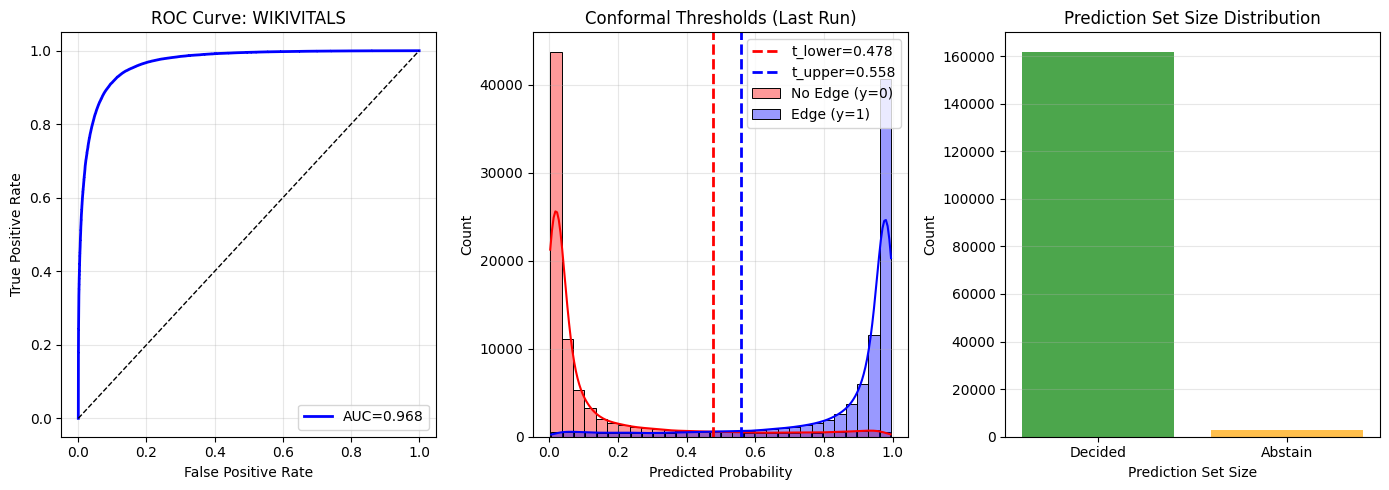

In [ ]:
results = run_directed_pipeline(
    adj_path="wikivitals/adjacency.tsv",
    name="Wikivitals",
    alpha=0.10,
    n_runs=10,
    n_components=32
)



**Observations:**
- Coverage exceeds the 90% target as expected (conformal prediction guarantees *at least* 1-α)
- Very low abstention means the model is confident on most predictions
- The two class distributions (edge vs non-edge) are well-separated

**Next steps:**
1. Print some example predictions to see what the model decides
2. Visualize conditional coverage (by node degree, by category)
3. Try another directed graph dataset for comparison